# Medium Post Notebook

First we import the basic libraries and define our setting:
- we specify the expected payoff of each call template and the expected duration of the script.
- In reality, both these quantities are unknown.
- We assume that the company restricts each call to a length of at maximum 10 minutes. We use this to normalize the call durations.

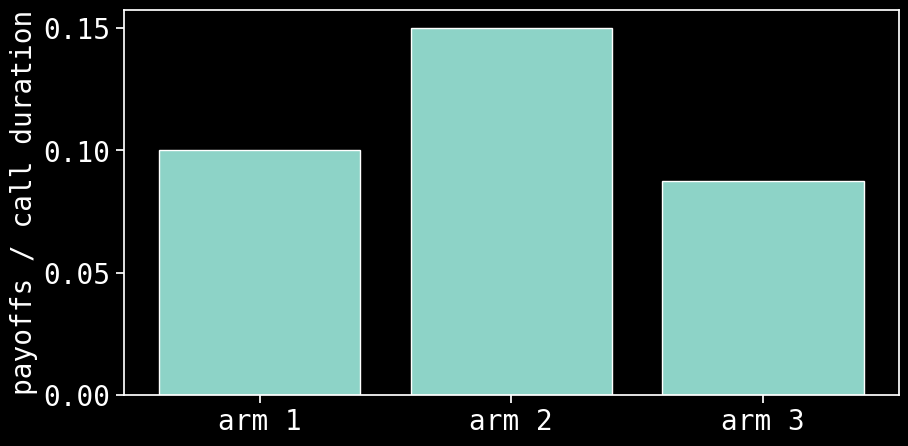

In [1]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="ticks")
plt.style.use("dark_background")

import matplotlib as mpl
fontsize = 20
params = {
    'legend.frameon': True,
    'figure.figsize': (10, 5),
    'font.sans-serif': 'DejaVu Sans Mono',
    'font.size': fontsize,
    'axes.labelsize': fontsize,
    'axes.titlesize': fontsize, 
    'legend.fontsize': fontsize, 
    'xtick.labelsize': fontsize, 
    'ytick.labelsize': fontsize}
mpl.rcParams.update(params)

expected_payoffs = np.array([0.1, 0.3, 0.7])
expected_duration_minutes = np.array([1, 2, 8])
maximum_duration = 10.0

expected_costs = expected_duration_minutes / maximum_duration
min_cost =  1e-2
max_minutes = 10000
n_samples = int(max_minutes)
rng = np.random.default_rng(0)

label_random = "random script"
colors = {
    "script 1": "magenta",
    "script 2": "deepskyblue",
    "script 3": "lime",
    label_random: "cyan",
    "UCB": "white",
    "scaled UCB": "white",
    "united":"white",
    "w-UCB": "yellow",
    "reductive": "navajowhite",
    "composite": "mediumorchid",
}

class Result:
    def  __init__(self, x, y, label, color):
        self.x = x
        self.y = y
        self.label = label
        self.color = color

all_results = []

plt.bar([f"arm {i + 1}" for i in range(len(expected_payoffs))], expected_payoffs / expected_duration_minutes)
plt.ylabel("payoffs / call duration")
plt.savefig(os.path.join(os.getcwd(), "figures", "arms_medium.png"))

## UCB sampling

First, let's look at standard UCB sampling.

For `n_samples` time steps, we pull the arm with the highest UCB. In each time step, we update the UCB for all arms, not just the one that we played as the confidence interval is a function of time. 

In [2]:
def compute_ci(n, t):
    if n == 0 or t == 0:
        return np.infty
    return np.sqrt(2 * np.log(t) / n)

def get_best_arm(data: pd.DataFrame):
    best_arm_index = np.argmax(data["ucb"]) 
    row = data.iloc[best_arm_index]
    return row["arm"]

payoffs = rng.uniform(size=(len(expected_payoffs), n_samples)) < np.expand_dims(expected_payoffs, -1)
columns=["arm", 'time', "plays", 'mean', 'ci', 'lcb', 'ucb', 'reward']

reward = 0
timestep_df = []
data = []
for i in range(n_samples):
    if i < len(expected_payoffs):
        played_arm = i
    else:
        played_arm = get_best_arm(timestep_df)
    rows_for_timestep = []
    for arm in range(len(expected_payoffs)):
        if i > 0:
            last_row_for_arm = timestep_df.iloc[arm]
            last_mean = last_row_for_arm["mean"]
            last_number_plays = last_row_for_arm["plays"]
        else:
            last_mean = 0
            last_number_plays = 0
        if arm == played_arm:
            sample = payoffs[arm, i]
            reward += sample
            new_plays = last_number_plays + 1
            new_mean = ((last_mean * last_number_plays) + sample) / new_plays
        else:
            new_mean = last_mean
            new_plays = last_number_plays
        new_ci = compute_ci(new_plays, i)
        rows_for_timestep.append([arm, i, new_plays, new_mean, new_ci, new_mean - new_ci, new_mean + new_ci, reward])
        data.append([arm, i, new_plays, new_mean, new_ci, new_mean - new_ci, new_mean + new_ci, reward])
    timestep_df = pd.DataFrame(rows_for_timestep, columns=columns)

data = pd.DataFrame(data, columns=columns)
data["played"] = data.groupby("arm")["plays"].diff().astype("bool")

payoffs_strategy_best = np.cumsum(payoffs[np.argmax(expected_payoffs)])
payoffs_strategy_worst = np.cumsum(payoffs[np.argmin(expected_payoffs)])
randomly_played_arms = rng.integers(0, len(expected_payoffs), len(payoffs_strategy_best))
payoffs_strategy_random = np.cumsum([r[i] for r, i in zip(payoffs.T, randomly_played_arms)])

result_s3_time = Result(range(len(payoffs_strategy_best)), payoffs_strategy_best, "script 3", colors["script 3"])
result_s1_time = Result(range(len(payoffs_strategy_worst)), payoffs_strategy_worst, "script 1", colors["script 1"])
result_random_time = Result(range(len(payoffs_strategy_random)), payoffs_strategy_random, label_random, colors[label_random])

Script 3 maximizes rewards, while script 1 is the worst. Choosing a random script lies inbetween.

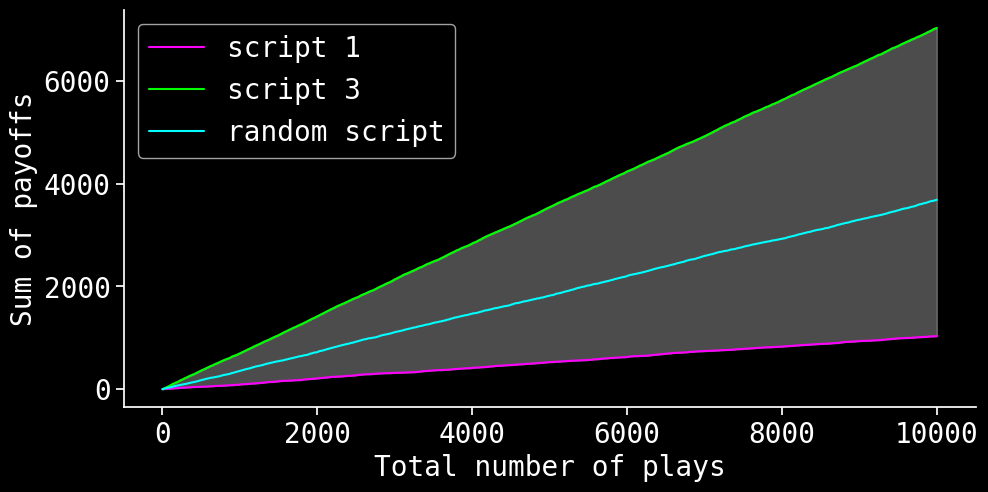

In [3]:
all_results = [result_s1_time, result_s3_time, result_random_time]

plt.fill_between(result_s3_time.x, result_s3_time.y, result_s1_time.y, color="white", alpha=0.3)
for result in all_results:
    ax = sns.lineplot(x=result.x, y=result.y, color=result.color, label=result.label, errorbar=None)

sns.move_legend(ax, "upper left")
sns.despine()
plt.xlabel("Total number of plays")
plt.ylabel("Sum of payoffs")
plt.tight_layout(pad=.5)
plt.savefig(os.path.join(os.getcwd(), "figures", "medium_1.png"))

In our simple example, UCB sampling figures out very quickly what the best arm is.

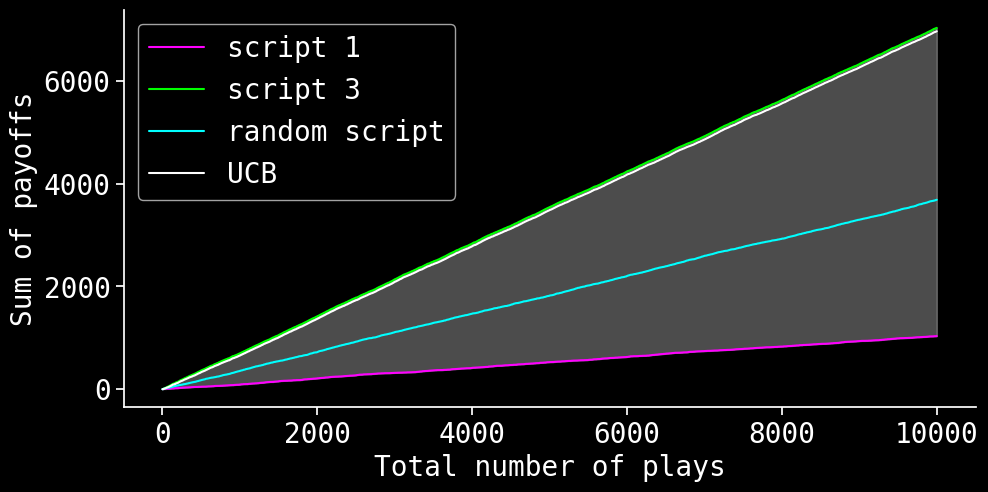

In [4]:
payoffs_ucb1 = np.array(data.loc[data["arm"] == 0]["reward"])
result_ucb_time = Result(range(len(payoffs_ucb1)), payoffs_ucb1, "UCB", colors["UCB"])

all_results = [result_s1_time, result_s3_time, result_random_time, result_ucb_time]

plt.fill_between(result_s3_time.x, result_s3_time.y, result_s1_time.y, color="white", alpha=0.3)
for result in all_results:
    ax = sns.lineplot(x=result.x, y=result.y, color=result.color, label=result.label)

sns.move_legend(ax, "upper left")
sns.despine()
plt.legend()
plt.xlabel("Total number of plays")
plt.ylabel("Sum of payoffs")
plt.tight_layout(pad=.5)
plt.savefig(os.path.join(os.getcwd(), "figures", "medium_2.png"))

## Why the budget matters

Now, let's have a look what happens if we take into account the costs of the calls. For this, we change the x-axis from "time" to "total call duration".
We first sample the costs from a Beta distribution with parameter `p=2` and parameter `q` adjusted so that the expected value of the distribution matches the expected call duration we specified earlier.

We can also compute a "bang for buck" ratio. This already indicates that, now, arm 2 provides the steepest increase in rewards.

In [5]:
payoff_per_minute = expected_payoffs / (expected_costs * maximum_duration)

# sample the costs from a beta distribution
p = 2
def q_for_p(p, expected_val):
    e_inv = 1 / expected_val
    return p / expected_val - p

def bernoulli(p):
    return int(rng.uniform() < p)

def sample(func, *args):
    return func(*args)

params = [(p, q_for_p(p, e)) for e in expected_costs]
# params = [[e] for e in expected_costs]
costs = np.array([[sample(rng.beta, *args) for args in params] 
                  for _ in range(n_samples)]).T

payoff_per_minute

array([0.1   , 0.15  , 0.0875])

The following graph confirms this:
Script 2 now is superior, while script 3 now is the worst. Note that our UCB algorithm from before now fails due to its inability to account for the costs.

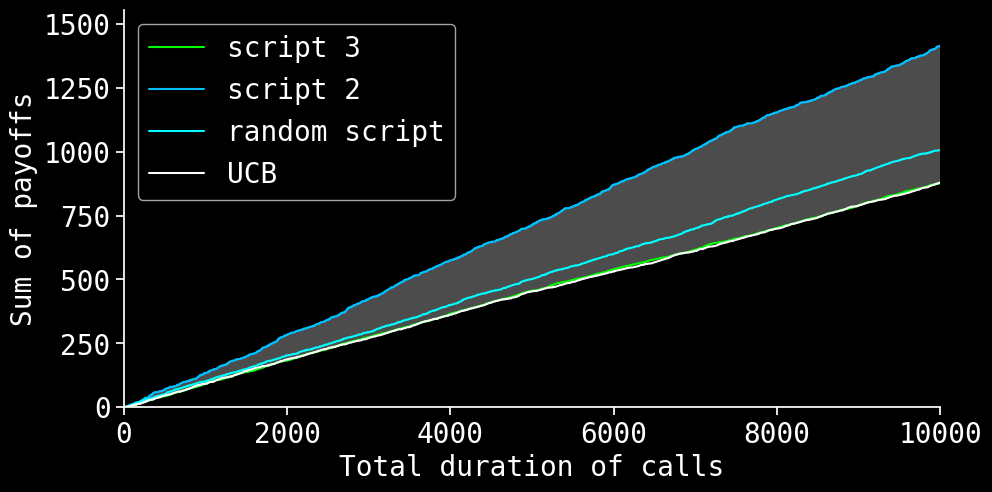

In [6]:
idx_best = np.argmax(payoff_per_minute)
idx_worst = np.argmin(payoff_per_minute)

payoffs_strategy_best = np.cumsum(payoffs[idx_best])
payoffs_strategy_worst = np.cumsum(payoffs[idx_worst])

minutes_best = costs[idx_best, :].cumsum() * maximum_duration # np.arange(len(payoffs_strategy_best)) * expected_duration_minutes[idx_best]
minutes_worst = costs[idx_worst, :].cumsum() * maximum_duration  # np.arange(len(payoffs_strategy_worst)) * expected_duration_minutes[idx_worst]
minutes_random = np.array([expected_duration_minutes[randomly_played_arms[i]] for i in range(n_samples)]).cumsum()

result_best_minutes = Result(minutes_best, payoffs_strategy_best, f"script {idx_best + 1}", colors[f"script {idx_best + 1}"])
result_worst_minutes = Result(minutes_worst, payoffs_strategy_worst, f"script {idx_worst + 1}", colors[f"script {idx_worst + 1}"])
result_random_minutes = Result(minutes_random, result_random_time.y, result_random_time.label, result_random_time.color)

payoffs_strategy_worst_stratified = []
for m_best in minutes_best:
    pay_worst = [p for p, m_worst in zip(payoffs_strategy_worst, minutes_worst) if m_worst <= m_best]
    payoffs_strategy_worst_stratified.append(pay_worst[-1] if len(pay_worst) else 0.0) 

result_worst_stratified = Result(minutes_best, payoffs_strategy_worst_stratified, "", "")

played_arms_ucb = np.array(data[data["played"]]["arm"])
minutes_ucb = np.array([costs[int(played_arms_ucb[i]), i] for i in range(n_samples)]).cumsum() * maximum_duration
result_ucb_minutes = Result(minutes_ucb, result_ucb_time.y, result_ucb_time.label, result_ucb_time.color)

all_results = [result_worst_minutes, result_best_minutes, result_random_minutes, result_ucb_minutes]
plt.fill_between(minutes_best, result_best_minutes.y, result_worst_stratified.y, color="white", alpha=0.3)
for result in all_results:
    ax = sns.lineplot(x=result.x, y=result.y, color=result.color, label=result.label, errorbar=None)

sns.move_legend(ax, "upper left")
sns.despine()

# max_minutes = np.max(minutes_best)
max_payoff = payoffs_strategy_best[len([m for m in minutes_best if m < max_minutes]) - 1]
plt.xlim(0, max_minutes)
plt.ylim(0, max_payoff * 1.1)
plt.xlabel("Total duration of calls")
plt.ylabel("Sum of payoffs")
plt.tight_layout(pad=.5)

plt.savefig(os.path.join(os.getcwd(), "figures", "medium_3.png"))

However, if we know the expected costs, we can scale the observed reward accordingly. The resulting strategy works quite well again.

In [7]:
def get_best_arm(data: pd.DataFrame):
    best_arm_index = np.argmax(data["ucb"]) 
    row = data.iloc[best_arm_index]
    return row["arm"]

def compute_ci(n, t):
    if n == 0 or t == 0:
        return np.infty
    return np.sqrt(2 * np.log(t) / n)

columns=["arm", 'time', "plays", 'mean', 'ci', 'lcb', 'ucb', 'reward']
reward = 0
timestep_df = []
data_ucb_scaled = []
for i in range(n_samples):
    if i < len(expected_payoffs):
        played_arm = i
    else:
        played_arm = get_best_arm(timestep_df)
    rows_for_timestep = []
    for arm in range(len(expected_payoffs)):
        cost_expectation = expected_costs[arm]
        if i > 0:
            last_row_for_arm = (timestep_df.iloc[arm])
            last_mean = last_row_for_arm["mean"]
            last_number_plays = last_row_for_arm["plays"]
        else:
            last_mean = 0
            last_number_plays = 0
        if arm == played_arm:
            sample = payoffs[arm, i]
            reward += sample
            new_plays = last_number_plays + 1
            new_mean = ((last_mean * last_number_plays) + sample) / new_plays
        else:
            new_mean = last_mean
            new_plays = last_number_plays
        new_ci = compute_ci(new_plays, i)
        rows_for_timestep.append([arm, i, new_plays, new_mean, new_ci, 
                                                       new_mean - new_ci, 
                                                       (new_mean + new_ci) / cost_expectation, reward])
        data_ucb_scaled.append([arm, i, new_plays, new_mean, new_ci, 
                                                       new_mean - new_ci, 
                                                       (new_mean + new_ci) / cost_expectation, reward])
    timestep_df = pd.DataFrame(rows_for_timestep, columns=columns)

data_ucb_scaled = pd.DataFrame(data_ucb_scaled, columns=columns)
data_ucb_scaled["played"] = data_ucb_scaled.groupby("arm")["plays"].diff().astype("bool")

payoffs_ucb_scaled = np.array(data_ucb_scaled.loc[data_ucb_scaled["arm"] == 0]["reward"])
played_arms_ucb_scaled = np.array(data_ucb_scaled[data_ucb_scaled["played"]]["arm"])
minutes_ucb_scaled = np.array([costs[int(played_arms_ucb_scaled[i]), i] for i in range(n_samples)]).cumsum() * maximum_duration

result_ucb_scaled = Result(minutes_ucb_scaled, payoffs_ucb_scaled, "scaled UCB", colors["scaled UCB"])

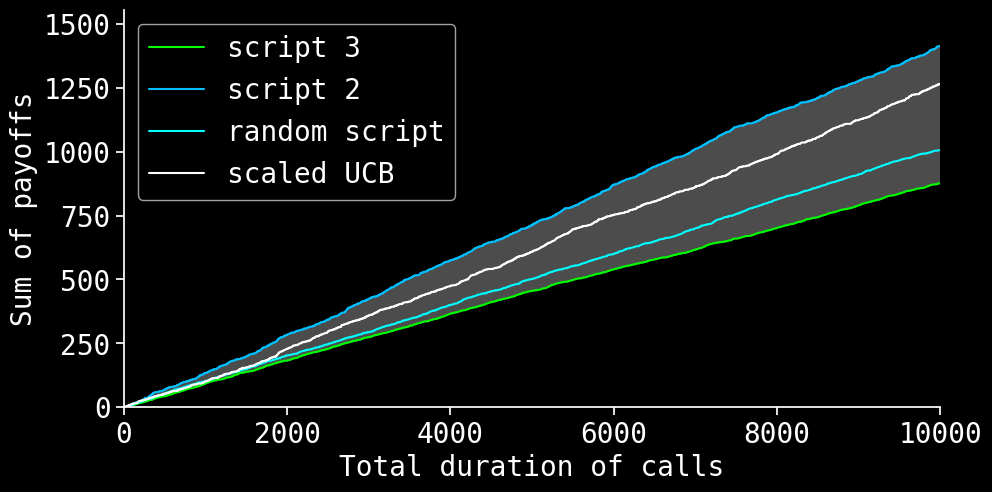

In [8]:
all_results = [result_worst_minutes, result_best_minutes, result_random_minutes, result_ucb_scaled]
plt.fill_between(minutes_best, result_best_minutes.y, result_worst_stratified.y, color="white", alpha=0.3)
for result in all_results:
    ax = sns.lineplot(x=result.x, y=result.y, color=result.color, label=result.label)

sns.move_legend(ax, "upper left")
sns.despine()

max_payoff = payoffs_strategy_best[len([m for m in minutes_best if m < max_minutes]) - 1]
plt.xlim(0, max_minutes)
plt.ylim(0, max_payoff * 1.1)
plt.xlabel("Total duration of calls")
plt.ylabel("Sum of payoffs")
plt.tight_layout(pad=.5)

plt.savefig(os.path.join(os.getcwd(), "figures", "medium_3_1.png"))

## Random costs

The next cells execute and plot the *reductive*, *united*, and *composite* baseline policies for budgeted multi-armed bandits with random costs.

In [9]:
idx_best = np.argmax(payoff_per_minute)
idx_worst = np.argmin(payoff_per_minute)

payoffs_strategy_best = np.cumsum(payoffs[idx_best])
payoffs_strategy_worst = np.cumsum(payoffs[idx_worst])

minutes_best = costs[idx_best, :].cumsum() * maximum_duration # np.arange(len(payoffs_strategy_best)) * expected_duration_minutes[idx_best]
minutes_worst = costs[idx_worst, :].cumsum() * maximum_duration  # np.arange(len(payoffs_strategy_worst)) * expected_duration_minutes[idx_worst]
minutes_random = np.array([expected_duration_minutes[randomly_played_arms[i]] for i in range(n_samples)]).cumsum()

payoffs_strategy_worst_stratified = []
for m_best in minutes_best:
    pay_worst = [p for p, m_worst in zip(payoffs_strategy_worst, minutes_worst) if m_worst <= m_best]
    payoffs_strategy_worst_stratified.append(pay_worst[-1] if len(pay_worst) else 0.0) 

payoffs_strategy_random = np.cumsum([r[i] for r, i in zip(payoffs.T, randomly_played_arms)])
minutes_random = np.cumsum([c[i] for c, i in zip(costs.T, randomly_played_arms)]) * maximum_duration

result_best_minutes_random = Result(minutes_best, payoffs_strategy_best,  f"scipt {idx_best + 1}", result_best_minutes.color)
result_worst_minutes_random = Result(minutes_worst, payoffs_strategy_worst,  f"scipt {idx_worst + 1}", result_worst_minutes.color)
result_random_minutes = Result(minutes_random, payoffs_strategy_random,  result_random_minutes.label, result_random_minutes.color)

**Composite**

In [10]:
def compute_ci(n, t):
    if t == 0 or n == 0:
        return np.infty
    return np.sqrt(2 * np.log(t) / n) 

def get_best_arm(data: pd.DataFrame):
    best_arm_index = np.argmax(data["ucb payoff"] / np.maximum(data["lcb cost"], 1e-10)) 
    row = data.iloc[best_arm_index]
    return row["arm"]

columns=["arm", 'time', "plays", 'mean payoff', 'mean cost', 'lcb cost', 'ucb payoff', 'reward', 'cost', "ci"]

reward = 0
cost = 0
data_composite = []
timestep_df = []
for i in range(n_samples):
    if i < len(expected_payoffs):
        played_arm = i
    else:
        played_arm = get_best_arm(timestep_df)
    rows_for_timestep = []
    for arm in range(len(expected_payoffs)):
        if i > 0:
            last_row_for_arm = (timestep_df.iloc[arm])
            last_mean_reward = last_row_for_arm["mean payoff"]
            last_mean_cost = last_row_for_arm["mean cost"]
            last_number_plays = last_row_for_arm["plays"]
        else:
            last_mean_reward = 0
            last_mean_cost = 0
            last_number_plays = 0
        if arm == played_arm:
            this_reward = payoffs[arm, i]
            this_cost = costs[arm, i]
            reward += this_reward
            cost += this_cost
            new_plays = last_number_plays + 1
            new_mean_reward = ((last_mean_reward * last_number_plays) + this_reward) / new_plays
            new_mean_cost = ((last_mean_cost * last_number_plays) + this_cost) / new_plays
        else:
            new_mean_reward = last_mean_reward
            new_mean_cost = last_mean_cost
            new_plays = last_number_plays
        new_ci = compute_ci(new_plays, i)
        rows_for_timestep.append([arm, i, new_plays, new_mean_reward, new_mean_cost, new_mean_cost - new_ci, new_mean_reward + new_ci, reward, cost, new_ci])
        data_composite.append([arm, i, new_plays, new_mean_reward, new_mean_cost, new_mean_cost - new_ci, new_mean_reward + new_ci, reward, cost, new_ci])
    timestep_df = pd.DataFrame(rows_for_timestep, columns=columns)

data_composite = pd.DataFrame(data_composite, columns=columns)
data_composite["played"] = data_composite.groupby("arm")["plays"].diff().astype("bool")

payoffs_composite = np.array(data_composite.loc[data_composite["arm"] == 0]["reward"])
played_arms_composite = np.array(data_composite[data_composite["played"]]["arm"])
minutes_composite = np.array(data_composite.loc[data_composite["arm"] == 0]["cost"]) * maximum_duration

result_composite = Result(minutes_composite, payoffs_composite,  "composite", colors["composite"])

idx_best = np.argmax(payoff_per_minute)
idx_worst = np.argmin(payoff_per_minute)

payoffs_strategy_best = np.cumsum(payoffs[idx_best])
payoffs_strategy_worst = np.cumsum(payoffs[idx_worst])

minutes_best = costs[idx_best, :].cumsum() * maximum_duration # np.arange(len(payoffs_strategy_best)) * expected_duration_minutes[idx_best]
minutes_worst = costs[idx_worst, :].cumsum() * maximum_duration  # np.arange(len(payoffs_strategy_worst)) * expected_duration_minutes[idx_worst]
minutes_random = np.array([expected_duration_minutes[randomly_played_arms[i]] for i in range(n_samples)]).cumsum()

payoffs_strategy_worst_stratified = []
for m_best in minutes_best:
    pay_worst = [p for p, m_worst in zip(payoffs_strategy_worst, minutes_worst) if m_worst <= m_best]
    payoffs_strategy_worst_stratified.append(pay_worst[-1] if len(pay_worst) else 0.0) 

payoffs_strategy_random = np.cumsum([r[i] for r, i in zip(payoffs.T, randomly_played_arms)])
minutes_random = np.cumsum([c[i] for c, i in zip(costs.T, randomly_played_arms)]) * maximum_duration

result_best_minutes_random = Result(minutes_best, payoffs_strategy_best,  f"scipt {idx_best + 1}", result_best_minutes.color)
result_worst_minutes_random = Result(minutes_worst, payoffs_strategy_worst,  f"scipt {idx_worst + 1}", result_worst_minutes.color)
result_random_minutes = Result(minutes_random, payoffs_strategy_random,  result_random_minutes.label, result_random_minutes.color)

**Reductive**: Here, we scale the interval of the reward-cost ratio by 1 / min_cost. Note that min_cost is unknown in general.

In [11]:
def compute_ci(n, t):
    if t == 0 or n == 0:
        return np.infty
    max_ratio = 1 / min_cost
    return  max_ratio * np.sqrt(2 * np.log(t) / n)

def get_best_arm(data: pd.DataFrame):
    try:
        best_arm_index = np.argmax(data["mean payoff"] / data["mean cost"] + data["ci"])
    except:
        return rng.choice(range(len(expected_payoffs)))
    row = data.iloc[best_arm_index]
    return row["arm"]

columns = ["arm", 'time', "plays", 
                             'mean payoff', 'mean cost', 
                             'lcb cost', 'ucb payoff', 
                             'reward', 'cost', "ci"]

reward = 0
cost = 0
data_reductive = []
timestep_df = []
for i in range(n_samples):
    if i < len(expected_payoffs):
        played_arm = i
    else:
        played_arm = get_best_arm(timestep_df)
    rows_for_timestep = []
    for arm in range(len(expected_payoffs)):
        if i > 0:
            last_row_for_arm = timestep_df.iloc[arm]
            last_mean_reward = last_row_for_arm["mean payoff"]
            last_mean_cost = last_row_for_arm["mean cost"]
            last_number_plays = last_row_for_arm["plays"]
        else:
            last_mean_reward = 0
            last_mean_cost = 0
            last_number_plays = 0
        
        if arm == played_arm:
            this_reward = payoffs[arm, i]
            this_cost = costs[arm, i]
            reward += this_reward
            cost += this_cost
            new_plays = last_number_plays + 1
            new_mean_reward = ((last_mean_reward * last_number_plays) + this_reward) / new_plays
            new_mean_cost = ((last_mean_cost * last_number_plays) + this_cost) / new_plays
        else:
            new_mean_reward = last_mean_reward
            new_mean_cost = last_mean_cost
            new_plays = last_number_plays
        new_ci = compute_ci(new_plays, i)
        rows_for_timestep.append([arm, i, new_plays, new_mean_reward, new_mean_cost, new_mean_cost - new_ci, new_mean_reward + new_ci, reward, cost, new_ci])
        data_reductive.append([arm, i, new_plays, new_mean_reward, new_mean_cost, new_mean_cost - new_ci, new_mean_reward + new_ci, reward, cost, new_ci])
    timestep_df = pd.DataFrame(rows_for_timestep, columns=columns)

data_reductive = pd.DataFrame(data_reductive, columns=columns)
data_reductive["played"] = data_reductive.groupby("arm")["plays"].diff().astype("bool")

payoffs_reductive = data_reductive.loc[data_reductive["played"]]["reward"]
minutes_reductive = data_reductive.loc[data_reductive["played"]]["cost"] * maximum_duration

result_reductive = Result(minutes_reductive, payoffs_reductive, "reductive", colors["reductive"])

**United**

In [12]:
def compute_ci(n, t):
    if t == 0 or n == 0:
        return np.infty
    return  np.sqrt(2 * np.log(t) / n)

def get_best_arm(data: pd.DataFrame):
    index = (data["mean payoff"] + data["ci"]) / data["mean cost"]
    index[index.isna()] = np.infty
    best_arm_index = np.argmax(index)
    row = data.iloc[best_arm_index]
    return row["arm"]

columns=["arm", 'time', "plays", 'mean payoff', "mean cost", 'lcb cost', 'ucb payoff', 'reward', 'cost', "ci"]

reward = 0
cost = 0
data_united = []
timestep_df = []
for i in range(n_samples):
    if i < len(expected_payoffs):
        played_arm = i
    else:
        played_arm = get_best_arm(timestep_df)
    rows_for_timestep = []
    for arm in range(len(expected_payoffs)):
        if i > 0:
            last_row_for_arm = timestep_df.iloc[arm]
            last_mean_reward = last_row_for_arm["mean payoff"]
            last_mean_cost = last_row_for_arm["mean cost"]
            last_number_plays = last_row_for_arm["plays"]
        else:
            last_mean_reward = 0.0
            last_mean_cost = 0.0
            last_number_plays = 0
        if arm == played_arm:
            this_reward = payoffs[arm, i]
            this_cost = costs[arm, i]
            reward += this_reward
            cost += this_cost
            new_plays = last_number_plays + 1
            new_mean_reward = ((last_mean_reward * last_number_plays) + this_reward) / new_plays
            new_mean_cost = ((last_mean_cost * last_number_plays) + this_cost) / new_plays
        else:
            new_mean_reward = last_mean_reward
            new_mean_cost = last_mean_cost
            new_plays = last_number_plays
        new_ci = compute_ci(new_plays, i)
        rows_for_timestep.append([arm, i, new_plays, new_mean_reward, new_mean_cost, new_mean_cost - new_ci, new_mean_reward + new_ci, reward, cost, new_ci])
        data_united.append([arm, i, new_plays, new_mean_reward, new_mean_cost, new_mean_cost - new_ci, new_mean_reward + new_ci, reward, cost, new_ci])
    timestep_df = pd.DataFrame(rows_for_timestep, columns=columns)

data_united = pd.DataFrame(data_united, columns=columns)
data_united["played"] = data_united.groupby("arm")["plays"].diff().astype("bool")

payoffs_united = data_united.loc[data_united["played"]]["reward"]
minutes_united = data_united.loc[data_united["played"]]["cost"] * maximum_duration
result_united = Result(minutes_united, payoffs_united,  "united", colors["united"])

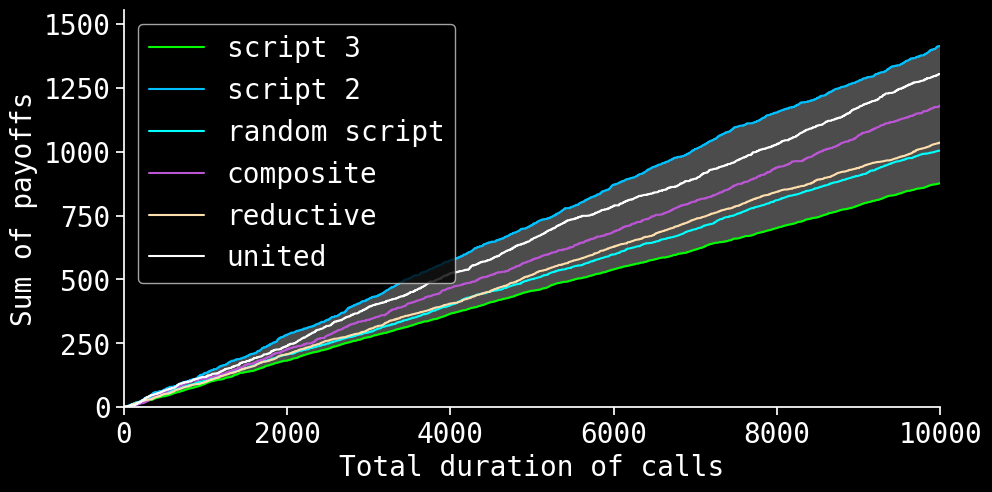

In [13]:
all_results = [result_worst_minutes, result_best_minutes, result_random_minutes, result_composite, result_reductive, result_united]
plt.fill_between(minutes_best, result_best_minutes.y, result_worst_stratified.y, color="white", alpha=0.3)
for result in all_results:
    ax = sns.lineplot(x=result.x, y=result.y, color=result.color, label=result.label, errorbar=None)

sns.move_legend(ax, "upper left")
sns.despine()
max_payoff = payoffs_strategy_best[len([m for m in minutes_best if m < max_minutes])]
plt.xlim(0, max_minutes)
plt.ylim(0, max_payoff * 1.1)
plt.xlabel("Total duration of calls")
plt.ylabel("Sum of payoffs")
plt.tight_layout(pad=.5)

plt.savefig(os.path.join(os.getcwd(), "figures", "medium_4.png"))

At last, we showcase our approach w-UCB. We use the `Aggregate` class from our repo to efficiently track the variance of the reward and cost distributions. We estimate the eta-parameter from the observed variance. 

We see that w-UCB figures out much faster which arm has the highest bang for buck than the other approaches. This is due to
1. our asymmetric confidence intervals and
2. the estimation of eta, which makes our intervals tighter when the distributions have small variance.

Feel free to play around with the parameters and approaches to see how they behave under different scenarios!

In [14]:
from components.bandits.bandit_util import Aggregate

def compute_eta(mean, variance):
    if mean == 0.0 or mean == 1.0:
        return 1.0
    eta = variance / (mean * (1.0 - mean))
    return min(eta, 1.0)

def compute_asymmetric_ci(mean, n, t, rho=0.25, eta: float = 1.0):
    if n == 0 or t == 0:
        return 0.0, np.infty
    z = np.sqrt(2 * rho * np.log(t))
    z2 = z ** 2 * eta
    z = np.sqrt(z2)
    ns = mean * n  # number of successes
    nf = n - ns # number of failures
    center = (ns + 0.5 * z2) / (n + z2)  # interval center
    ci = z / (n + z2) * np.sqrt((ns * nf) / n + z2 / 4)  # interval width
    return center - ci, center + ci

columns=["arm", 'time', "plays", 
                             'mean payoff', 'mean cost', 
                             'lcb cost', 'ucb payoff', 
                             'reward', 'cost', "ci"]

def get_best_arm(data: pd.DataFrame):
    index = data["ucb payoff"] / data["lcb cost"]
    index[index.isna()] = 1 / min_cost
    return np.argmax(index)

reward = 0
cost = 0
rew_aggregates = [Aggregate() for _ in range(len(expected_payoffs))]
cost_aggregates = [Aggregate() for _ in range(len(expected_payoffs))]

data_omega_star = []
timestep_df = []
for i in range(n_samples):
    if i < len(expected_payoffs):
        played_arm = i
    else:
        played_arm = get_best_arm(timestep_df)
    rows_for_timestep = []
    for arm in range(len(expected_payoffs)):
        if i > 0:
            last_row_for_arm = timestep_df.iloc[arm]
            last_mean_reward = last_row_for_arm["mean payoff"]
            last_mean_cost = last_row_for_arm["mean cost"]
            last_number_plays = last_row_for_arm["plays"]
        else:
            last_mean_reward = 0
            last_mean_cost = 0
            last_number_plays = 0
        if arm == played_arm:
            this_reward = payoffs[arm, i]
            this_cost = costs[arm, i]
            reward += this_reward
            cost += this_cost
            new_plays = last_number_plays + 1
            new_mean_reward = ((last_mean_reward * last_number_plays) + this_reward) / new_plays
            new_mean_cost = ((last_mean_cost * last_number_plays) + this_cost) / new_plays
            rew_aggregates[arm].update(this_reward)
            cost_aggregates[arm].update(this_cost)
        else:
            new_mean_reward = last_mean_reward
            new_mean_cost = last_mean_cost
            new_plays = last_number_plays
        lcb_cost, _ = compute_asymmetric_ci(new_mean_cost, new_plays, i,
                                            eta=compute_eta(cost_aggregates[arm].mean(), cost_aggregates[arm].variance()))
        _, ucb_payoff = compute_asymmetric_ci(new_mean_reward, new_plays, i,
                                              eta=compute_eta(rew_aggregates[arm].mean(), rew_aggregates[arm].variance()))
        rows_for_timestep.append([arm, i, new_plays, new_mean_reward, new_mean_cost, lcb_cost, ucb_payoff, reward, cost, new_mean_cost - lcb_cost])
        data_omega_star.append([arm, i, new_plays, new_mean_reward, new_mean_cost, lcb_cost, ucb_payoff, reward, cost, new_mean_cost - lcb_cost])
    timestep_df = pd.DataFrame(rows_for_timestep, columns=columns)

data_omega_star = pd.DataFrame(data_omega_star, columns=columns)
data_omega_star["played"] = data_omega_star.groupby("arm")["plays"].diff().astype("bool")

payoffs_omega_star = data_omega_star.loc[data_omega_star["played"]]["reward"]
minutes_omega_star = data_omega_star.loc[data_omega_star["played"]]["cost"] * maximum_duration

result_ours_star = Result(minutes_omega_star, payoffs_omega_star, "w-UCB", colors["w-UCB"])

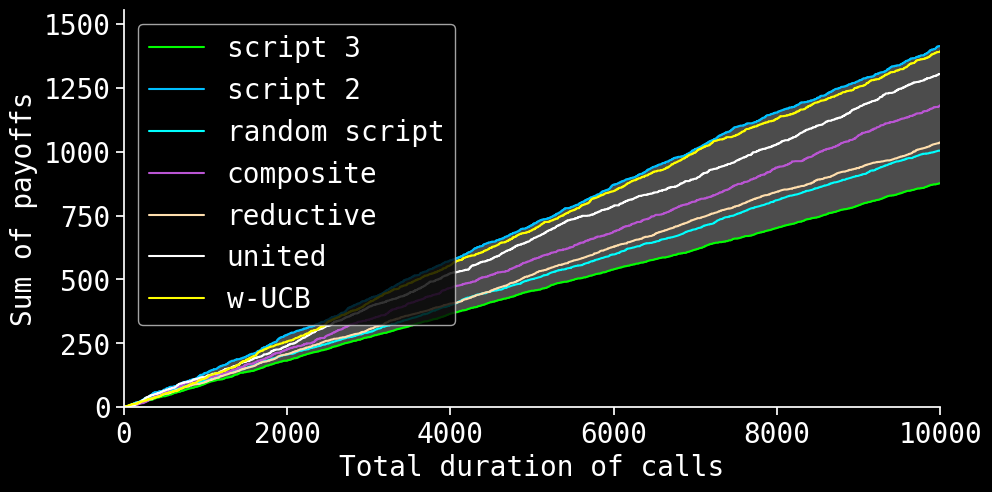

In [15]:
all_results = [result_worst_minutes, result_best_minutes, result_random_minutes, result_composite, result_reductive, result_united, result_ours_star]
plt.fill_between(minutes_best, result_best_minutes.y, result_worst_stratified.y, color="white", alpha=0.3)
for result in all_results:
    ax = sns.lineplot(x=result.x, y=result.y, color=result.color, label=result.label, errorbar=None)

sns.move_legend(ax, "upper left", frameon=True)
sns.despine()
max_payoff = payoffs_strategy_best[len([m for m in minutes_best if m < max_minutes]) - 1]
plt.xlim(0, max_minutes)
plt.ylim(0, max_payoff * 1.1)
plt.xlabel("Total duration of calls")
plt.ylabel("Sum of payoffs")
plt.tight_layout(pad=.5)

plt.savefig(os.path.join(os.getcwd(), "figures", "medium_5.png"))